In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("/GitHub/neuromap/src")

In [43]:
%matplotlib inline

from abc                  import abstractmethod
from numpy                import inf
from torch                import Tensor
from torch.nn             import Parameter
from torch.nn.functional  import softmax, sigmoid
from torch_geometric.nn   import GCN, GAT
from torch_geometric.data import Data
from typing               import Dict, List, Tuple

import networkx as nx
import torch
import os

In [44]:
# Prefer CUDA if available, else MPS (Apple Silicon), else CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
else:
    device = torch.device("cpu")
    
print("Device:", device)

Device: cpu


In [45]:
# create smart teleportation flow matrix and flow distribution as described
#  - https://arxiv.org/abs/2311.04036
#  - https://www.nature.com/articles/ncomms5630
def mkSmartTeleportationFlow(A, alpha = 0.15, iter = 1000, device=device):
    # build the transition matrix
    T = torch.nan_to_num(A.T * (torch.sum(A, 1)**(-1.0)).to_dense(), nan = 0.0).T.to(device = device)

    # distribution according to nodes' in-degrees
    e_v = (torch.sum(A, dim = 0) / torch.sum(A)).to_dense().to(device = device)

    # calculate the flow distribution with a power iteration
    p = e_v
    for _ in range(iter):
        p = alpha * e_v + (1-alpha) * p @ T
    
    # make the flow matrix for minimising the map equation
    F = alpha * A / torch.sum(A) + (1-alpha) * (p * T.T).T
    
    return F, p

In [46]:
# We encode the map equation loss in a pooling operator, but are actually
# only interested in the codelength for now
class MapEquationPooling(torch.nn.Module):
    def __init__(self, adj: Tensor, device=device, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)

        self.adj       = adj
        self.F, self.p = mkSmartTeleportationFlow(self.adj, device = device)

        # this term is constant, so only calculate it once
        self.p_log_p = torch.sum(self.p * torch.nan_to_num(torch.log2(self.p), nan = 0.0))

    def forward(self, x, s):
        C      = s.T @ self.F @ s
        diag_C = torch.diag(C)

        q   = 1.0 - torch.trace(C)
        q_m = torch.sum(C, dim = 1) - diag_C
        m_exit = torch.sum(C, dim = 0) - diag_C
        p_m = q_m + torch.sum(C, dim = 0)

        codelength = torch.sum(q      * torch.nan_to_num(torch.log2(q),      nan = 0.0)) \
                   - torch.sum(q_m    * torch.nan_to_num(torch.log2(q_m),    nan = 0.0)) \
                   - torch.sum(m_exit * torch.nan_to_num(torch.log2(m_exit), nan = 0.0)) \
                   - self.p_log_p \
                   + torch.sum(p_m    * torch.nan_to_num(torch.log2(p_m),    nan = 0.0))

        x_pooled   = torch.matmul(s.T, x)
        adj_pooled = s.T @ self.adj @ s

        return x_pooled, adj_pooled, codelength

In [47]:
def sparse_from_networkx(G : nx.Graph) -> Tuple[torch.Tensor, Dict[int, int]]:
    """
    Converts a networkx graph to a sparse tensor.

    Parameters
    ----------
    G : nx.Graph
        The networkx graph, which can be weighted and/or directed.

    Returns
    ------
    Tuple[torch.Tensor, Dict[int, int]]
        A tuple containing the sparse tensor representation of the input graph
        and a dictionary from zero-based IDs to the original node names.
    """

    # always make sure to sort the nodes so they're in the expected order
    the_nodes  = list(sorted(G.nodes))
    node_to_ID = { node:ID for (ID,node) in enumerate(the_nodes) }
    ID_to_node = { ID:node for (ID,node) in enumerate(the_nodes) }

    indices = [[],[]]
    values  = []
    for u in the_nodes:
        for v in sorted(G.neighbors(u)): # again, always sorting...
            weight = 1.0
            data   = G.get_edge_data(u, v)
            if "weight" in data:
                weight = data["weight"]
            indices[0].append(node_to_ID[u])
            indices[1].append(node_to_ID[v])
            values.append(float(weight))
    
    return ( torch.sparse_coo_tensor( indices = indices
                                    , values  = values
                                    , size    = (len(the_nodes), len(the_nodes))
                                    )
           , ID_to_node
           )

In [48]:
def to_dataset(G: nx.Graph, y_true: List[int]) -> Data:
    """
    Takes a networkx graph and a list of community labels for the nodes and
    returns them as a pyg Data representation.

    Parameters
    ----------
    G : nx.Graph
        The networkx graph.

    y_true : List[int]
        List of the nodes' community labels.

    Returns
    -------
    Data
        A Data object where the edge index and node features X are a sparse
        tensor representation of the graph's adjacency matrix and the node
        labels a the nodes' true communities.
    """
    data = Data()
    data.edge_index = sparse_from_networkx(G)[0].coalesce()
    data.x          = sparse_from_networkx(G)[0].coalesce()
    data.y          = torch.Tensor(y_true).long()

    return data

In [49]:
# A clusterer that runs the optimisation.
# The missing ingredient: a specific forward method (next cell).
class Clusterer(torch.nn.Module):
    def __init__(self, model, device=device) -> None:
        super().__init__()
        self.model = model
        self.device = device
        # Sposta tutti i Parameter/Buffer (incluso self.model) sul device
        self.to(self.device)

    @abstractmethod
    def forward(self, x):
        raise NotImplementedError(f"forward not implemented on {self._get_name()}")

    def fit(self, data: Data, epochs: int, patience: int, lr: float,Print=False):
        self.data = data.to(self.device)
        x = self.data.x.to_dense()

        l_best : float  = inf  # best loss
        s_best : Tensor = None # best cluster

        optimizer = torch.optim.Adam(self.parameters(), lr = lr)

        epoch          = 0
        no_improvement = 0

        while epoch < epochs and no_improvement < patience:
            self.train()
            optimizer.zero_grad()

            loss, s = self.forward(x = x)
            if Print==True:
                print(f"[Epoch {epoch:4}] L = {loss:.8f} bits")
            loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                loss, s = self.forward(x = x)

                if loss < l_best:
                    l_best         = float(loss)
                    no_improvement = 0
                    s_best         = s
                else:
                    no_improvement += 1

                epoch += 1


        return l_best, s_best

In [50]:
# Neuromap inherits from Clusterer and defines the specific forward method.
class Neuromap(Clusterer):
    def __init__(self, model, device=device) -> None:  #def __init__(self, model, device: str = "cpu") -> None:
        super().__init__(model = model, device = device)

        # softmax temperature
        self.t = Parameter(torch.zeros(1)).to(device = self.device)


    def forward(self, x):
        """
        #Debug
        #-------------------------------------
        print("x:", self.data.x.device,
              "edge_index:", self.data.edge_index.device,
              "model:", next(self.model.parameters()).device,
              "t:", self.t.device)
        #-------------------------------------
        """
        edge_index = self.data.edge_index
        if edge_index.device != x.device:
            edge_index = edge_index.to(x.device)
        s = softmax(self.model(x, edge_index) / sigmoid(self.t), dim = 1)

        if self.training:
            s = s + 1e-8

        _, _, loss = self.pool(x = x, s = s)

        return loss, s


    def fit(self, data: Data, epochs: int, patience: int, lr: float):
        self.data = data.to(device = self.device)
        self.pool = MapEquationPooling(adj=self.data.edge_index, device=self.device)
        
        return super().fit(data=self.data, epochs = epochs, patience = patience, lr = lr)

## Real network

In [100]:
states_path= "/Users/gabrielepoccianti/Documents/Information theory and Inference/Project/state_networks_graphml"
graph_path= os.path.join(states_path, "California.graphml") #California

#graph_path="E:\progetti\Information theory and Inference\Project\state_networks_graphml\California.graphml" #California
#graph_path="E:\progetti\Information theory and Inference\Project\state_networks_graphml\Texas.graphml"
G= nx.read_graphml(graph_path)

# Estrai automaticamente il nome dal file
G.name = os.path.splitext(os.path.basename(graph_path))[0]

print(f"Loaded graph: {G.name}")

Loaded graph: California


In [101]:
n = G.number_of_nodes()
data = to_dataset(G = G, y_true = [])

## Hyperparameter Selection

In [102]:
# ==== Hyperparameter search (GPU) - Random sampling OR Optuna (resume-safe, text tqdm) ====
import math, random, time, copy, os, re, json, tempfile
import torch
from torch_geometric.nn import GCN, GAT
from tqdm.std import tqdm  # barra testuale (no widget)

# ---------------- Configura qui ----------------
USE_OPTUNA   = True           # False -> random sampling; True -> Optuna
N_ITER       = 1             # numero di configurazioni da testare (trials)
RESTARTS     = 1              # ripetizioni per config (semi-robustezza)
HP_EPOCHS    = 600
HP_PATIENCE  = 80
SEED_BASE    = 123

# Lista reale di heads che vuoi esplorare (mappata via heads_idx in Optuna)
heads_grid = [2,4,8,32]

# Modelli disponibili
MODELS = {"GCN": GCN,
#          "GAT": GAT
         }

# Optuna: nome / storage (RIUSARE LO STESSO STUDY_NAME se LOAD_STUDY=True)
LOAD_STUDY   = True
STUDY_NAME   = "neuromap_hptune_"+(G.name if ("G" in globals() and hasattr(G, "name")) else "hptune")
STORAGE_URL  = "sqlite:///"+STUDY_NAME+".db"
# -----------------------------------------------

# GPU perf knobs
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

# Costruttori modelli (GAT: concat=False -> average the heads)
def build_model(model_type, in_channels, hidden_channels, num_layers, out_channels,
                act="selu", norm="batch", dropout=0.5, heads=1, concat_heads=False):
    if model_type == "GCN":
        return GCN(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            out_channels=out_channels,
            act=act,
            norm=norm,
            dropout=dropout
        )
    elif model_type == "GAT":
        return GAT(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            out_channels=out_channels,
            act=act,
            norm=norm,
            dropout=dropout,
            heads=heads,
            concat=concat_heads
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

# Move graph to GPU once
data_gpu = data.to(device)

# Run a single trial (train and return best L)
def run_one_trial(cfg, model_type="GCN", epochs=HP_EPOCHS, patience=HP_PATIENCE, seed=SEED_BASE, concat_heads=False):
    set_seed(seed)
    cfg_local = copy.deepcopy(cfg)
    used_heads = int(cfg_local.get("heads", 1))

    print(f"[run_one_trial] Building model: {model_type} | out_channels={cfg_local.get('out_channels')} | heads={used_heads} | concat_heads={concat_heads} | hidden={cfg_local.get('hidden_channels')} | layers={cfg_local.get('num_layers')}")
    try:
        model = build_model(
            model_type=model_type,
            in_channels=n,
            hidden_channels=int(cfg_local["hidden_channels"]),
            num_layers=int(cfg_local["num_layers"]),
            out_channels=int(cfg_local["out_channels"]),
            act=cfg_local.get("act", "selu"),
            norm=cfg_local.get("norm", "batch"),
            dropout=float(cfg_local.get("dropout", 0.5)),
            heads=used_heads,
            concat_heads=concat_heads
        ).to(device)
    except Exception as e:
        print(f"[error] Failed to build {model_type} model with cfg {cfg_local}: {e}")
        return float("inf"), used_heads

    nm = Neuromap(model=model, device=device)
    try:
        best_L, _ = nm.fit(data=data_gpu, epochs=epochs, patience=patience, lr=cfg_local["lr"])
    except Exception as e:
        print(f"[error] Training failed for {model_type} with cfg {cfg_local}: {e}")
        return float("inf"), used_heads

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return float(best_L), used_heads

# ---------- Griglia / grid per random sampling ----------
grid = {
    "hidden_channels": [max(16, n//2), n, min(4*n, 512)],
    "num_layers":      [2, 4, 6, 10],
    # out_channels ragionevoli dato che concat=False
    "out_channels":    [4, 8, 16, 24, 32],
    "dropout":         [0.0, 0.2, 0.5],
    "lr":              [3e-4, 1e-3, 3e-3, 1e-2, 1e-1],
    "act":             ["selu","relu","sigmoid"],
    "norm":            ["batch"],
    # per random sampling usiamo direttamente heads_grid
    "heads":           heads_grid,
    "concat_heads":    [False],   # default: average the heads
}

# ---------- Helper: random sampling ----------
def random_sample_configs(grid, n_iter, seed=SEED_BASE):
    rng = random.Random(seed)
    keys = list(grid.keys())
    return [{k: rng.choice(grid[k]) for k in keys} for _ in range(n_iter)]

best_score = math.inf
best_cfg   = None
best_model = None
best_model_heads = None
best_model_concat = None

if not USE_OPTUNA:
    print(f"Random sampling: N_ITER={N_ITER}")
    cfgs = random_sample_configs(grid, N_ITER, seed=SEED_BASE)
    with tqdm(total=len(cfgs) * len(MODELS), desc="Random search (GPU)") as pbar:
        for i, cfg in enumerate(cfgs, 1):
            for model_type in MODELS.keys():
                print(f"[random] Trial {i}/{len(cfgs)} — testing model {model_type} (heads={cfg.get('heads')})")
                scores, used_head_vals, concat_vals = [], [], []
                for r in range(RESTARTS):
                    try:
                        L_best, used_h = run_one_trial(cfg, model_type=model_type, seed=SEED_BASE + r, concat_heads=cfg.get("concat_heads", False))
                    except Exception as e:
                        print(f"[trial {i} restart {r} model {model_type}] ERROR: {e}")
                        L_best, used_h = math.inf, None
                    scores.append(L_best)
                    used_head_vals.append(used_h)
                    concat_vals.append(cfg.get("concat_heads", False))
                L_avg = float(sum(scores) / len(scores))
                used_head = next((h for h in used_head_vals if h is not None), None)
                used_concat = next((c for c in concat_vals if c is not None), False)
                if L_avg < best_score:
                    best_score, best_cfg, best_model, best_model_heads, best_model_concat = L_avg, copy.deepcopy(cfg), model_type, used_head, used_concat
                pbar.set_postfix({"L_avg": f"{L_avg:.5f}", "best": f"{best_score:.5f}", "model": best_model})
                pbar.update(1)
    BEST_PARAMS = copy.deepcopy(best_cfg)
    BEST_MODEL  = best_model
    BEST_MODEL_HEADS = best_model_heads
    BEST_MODEL_CONCAT = best_model_concat
    print("\nBEST (random):")
    print("  best_model:", BEST_MODEL)
    print("  best_params:", BEST_PARAMS)
    print("  best_model_heads:", BEST_MODEL_HEADS)
    print("  best_model_concat (concat heads?):", BEST_MODEL_CONCAT)
    print("  best_score:", best_score)

# ---------- Optuna variant ----------
else:
    import optuna
    from optuna.distributions import CategoricalDistribution

    # load study if requested (reuse same STUDY_NAME)
    if LOAD_STUDY:
        try:
            study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
            print(f"Loaded existing study: {STUDY_NAME}")
        except Exception:
            print(f"No existing study found. Creating new study: {STUDY_NAME}")
            study = optuna.create_study(study_name=STUDY_NAME, storage=STORAGE_URL, direction="minimize")
    else:
        study = optuna.create_study(study_name=STUDY_NAME, storage=STORAGE_URL, direction="minimize")

    # Stabilize categorical choices from study if present (for params other than heads_idx)
    def _stable_choices_from_study(param_name, default_list):
        def cast_list(lst):
            out = []
            for x in lst:
                if isinstance(x, (int,)) and not isinstance(x, bool):
                    out.append(int(x))
                elif isinstance(x, float):
                    out.append(float(x))
                else:
                    out.append(x)
            return out
        try:
            if len(study.trials) > 0:
                first = study.trials[0]
                dist = first.distributions.get(param_name)
                if isinstance(dist, CategoricalDistribution):
                    return cast_list(dist.choices)
        except Exception:
            pass
        return cast_list(default_list)

    hidden_choices = _stable_choices_from_study("hidden_channels", grid["hidden_channels"])
    num_layers_choices = _stable_choices_from_study("num_layers", grid["num_layers"])
    dropout_choices = _stable_choices_from_study("dropout", grid["dropout"])
    lr_choices = _stable_choices_from_study("lr", grid["lr"])
    act_choices = _stable_choices_from_study("act", grid["act"])
    norm_choices = _stable_choices_from_study("norm", grid["norm"])
    concat_choices = _stable_choices_from_study("concat_heads", grid.get("concat_heads", [False]))
    out_channels_choices = _stable_choices_from_study("out_channels", grid["out_channels"])

    # suggest_cfg: use heads_idx (int) mapped to heads_grid to avoid conflicts with any existing 'heads' categorical param
    def suggest_cfg(trial: optuna.Trial):
        # choose index for heads from the range of heads_grid
        heads_idx = trial.suggest_int("heads_idx", 0, len(heads_grid)-1)
        return {
            "hidden_channels": trial.suggest_categorical("hidden_channels", hidden_choices),
            "num_layers":      trial.suggest_categorical("num_layers", num_layers_choices),
            "out_channels":    trial.suggest_categorical("out_channels", out_channels_choices),
            "dropout":         trial.suggest_categorical("dropout", dropout_choices),
            "lr":              trial.suggest_categorical("lr", lr_choices),
            "act":             trial.suggest_categorical("act", act_choices),
            "norm":            trial.suggest_categorical("norm", norm_choices),
            # map index to actual heads value
            "heads":           heads_grid[heads_idx],
            "heads_idx":       heads_idx,               # saved for traceability
            "concat_heads":    trial.suggest_categorical("concat_heads", concat_choices),
        }

    pbar = tqdm(total=N_ITER, desc="Optuna (GPU)")

    def objective(trial: optuna.Trial):
        cfg = suggest_cfg(trial)
        best_val_for_cfg = math.inf
        best_model_for_cfg = None
        best_model_heads_for_cfg = None
        best_model_concat_for_cfg = None

        print(f"[optuna] Trial #{trial.number} — cfg: out={cfg.get('out_channels')} hidden={cfg.get('hidden_channels')} lr={cfg.get('lr')} concat={cfg.get('concat_heads')} heads={cfg.get('heads')} (idx={cfg.get('heads_idx')})")

        for model_type in MODELS.keys():
            print(f"[optuna] Trial #{trial.number} — testing model {model_type} (heads={cfg.get('heads')})")
            scores = []
            used_heads_vals = []
            concat_vals = []
            for r in range(RESTARTS):
                try:
                    L_best, used_h = run_one_trial(cfg, model_type=model_type, seed=SEED_BASE + r, concat_heads=cfg.get("concat_heads", False))
                except Exception as e:
                    print(f"[trial error model {model_type}] {e}")
                    L_best, used_h = float("inf"), None
                scores.append(L_best)
                used_heads_vals.append(used_h)
                concat_vals.append(cfg.get("concat_heads", False))
            val = float(sum(scores) / len(scores))
            if val < best_val_for_cfg:
                best_val_for_cfg = val
                best_model_for_cfg = model_type
                best_model_heads_for_cfg = next((h for h in used_heads_vals if h is not None), None)
                best_model_concat_for_cfg = next((c for c in concat_vals if c is not None), False)

        if best_model_for_cfg is not None:
            # save which model (and heads) won this trial
            trial.set_user_attr("best_model", best_model_for_cfg)
            trial.set_user_attr("best_model_heads", int(best_model_heads_for_cfg) if best_model_heads_for_cfg is not None else None)
            trial.set_user_attr("best_model_concat", bool(best_model_concat_for_cfg))
            print(f"[optuna] Trial #{trial.number} -> winner: {best_model_for_cfg} (heads={best_model_heads_for_cfg}, concat={best_model_concat_for_cfg}) L={best_val_for_cfg:.6f}")

        pbar.update(1)

        # update pbar postfix with global best if present
        try:
            best_val = study.best_value
        except Exception:
            pass
        else:
            try:
                pbar.set_postfix({"best": f"{best_val:.5f}"})
            except Exception:
                pass

        return float(best_val_for_cfg)

    try:
        study.optimize(objective, n_trials=N_ITER, show_progress_bar=False)
    finally:
        pbar.close()

    # retrieve best results
    best_trial = study.best_trial
    best_cfg = best_trial.params
    best_score = study.best_value

    best_model = best_trial.user_attrs.get("best_model", None)
    best_model_heads = best_trial.user_attrs.get("best_model_heads", None)
    best_model_concat = best_trial.user_attrs.get("best_model_concat", None)

    # normalize types and include heads_idx if present
    best_cfg_normalized = {
        "hidden_channels": int(best_cfg["hidden_channels"]),
        "num_layers": int(best_cfg["num_layers"]),
        "out_channels": int(best_cfg["out_channels"]),
        "dropout": float(best_cfg["dropout"]),
        "lr": float(best_cfg["lr"]),
        "act": best_cfg["act"],
        "norm": best_cfg["norm"],
        "heads": int(best_cfg.get("heads", heads_grid[0])),
        "heads_idx": int(best_cfg.get("heads_idx", 0)),
        "concat_heads": bool(best_cfg.get("concat_heads", False)),
    }

    BEST_PARAMS = copy.deepcopy(best_cfg_normalized)
    BEST_MODEL  = best_model
    BEST_MODEL_HEADS = int(best_model_heads) if best_model_heads is not None else None
    BEST_MODEL_CONCAT = bool(best_model_concat) if best_model_concat is not None else False

    print("\nBEST (optuna):")
    print("  best_model:", BEST_MODEL)
    print("  best_params:", BEST_PARAMS)
    print("  best_model_heads:", BEST_MODEL_HEADS)
    print("  best_model_concat (concat heads?):", BEST_MODEL_CONCAT)
    print("  best_score:", best_score)

# ----------------------- Save JSON -----------------------
if "G" in globals() and hasattr(G, "name") and G.name:
    name_part = str(G.name)
elif "STUDY_NAME" in globals() and STUDY_NAME:
    name_part = str(STUDY_NAME)
else:
    name_part = "hptune"
name_part = re.sub(r'[^A-Za-z0-9._-]+', '_', name_part).strip("._-") or "hptune"

out_dir = "hp_results"
os.makedirs(out_dir, exist_ok=True)
json_path = os.path.join(out_dir, f"{name_part}.json")

payload = {
    "network_name": name_part,
    "best_params": BEST_PARAMS if "BEST_PARAMS" in globals() else None,
    "best_score": float(best_score) if "best_score" in globals() else None,
    "best_model": BEST_MODEL if "BEST_MODEL" in globals() else None,
    "best_model_heads": BEST_MODEL_HEADS if "BEST_MODEL_HEADS" in globals() else None,
    "best_model_concat": BEST_MODEL_CONCAT if "BEST_MODEL_CONCAT" in globals() else None,
    "method": "optuna" if ("USE_OPTUNA" in globals() and USE_OPTUNA) else "random",
    "n_iter": int(N_ITER) if "N_ITER" in globals() else None,
    "restarts": int(RESTARTS) if "RESTARTS" in globals() else None,
    "seed_base": int(SEED_BASE) if "SEED_BASE" in globals() else None,
    "study_name": STUDY_NAME if "STUDY_NAME" in globals() else None,
    "storage_url": STORAGE_URL if "STORAGE_URL" in globals() else None,
}

with tempfile.NamedTemporaryFile("w", delete=False, dir=out_dir, suffix=".json", encoding="utf-8") as tf:
    json.dump(payload, tf, indent=2, ensure_ascii=False)
    temp_json = tf.name
os.replace(temp_json, json_path)
print(f"Saved BEST params -> {json_path}")

Loaded existing study: neuromap_hptune_California


Optuna (GPU):   0%|          | 0/1 [00:00<?, ?it/s]

[optuna] Trial #207 — cfg: out=8 hidden=232 lr=0.01 concat=False heads=32 (idx=3)
[optuna] Trial #207 — testing model GCN (heads=32)
[run_one_trial] Building model: GCN | out_channels=8 | heads=32 | concat_heads=False | hidden=232 | layers=2


Optuna (GPU): 100%|██████████| 1/1 [00:01<00:00,  1.78s/it, best=5.30898]

[optuna] Trial #207 -> winner: GCN (heads=32, concat=False) L=5.308980

BEST (optuna):
  best_model: GCN
  best_params: {'hidden_channels': 232, 'num_layers': 2, 'out_channels': 32, 'dropout': 0.2, 'lr': 0.01, 'act': 'selu', 'norm': 'batch', 'heads': 2, 'heads_idx': 3, 'concat_heads': False}
  best_model_heads: 32
  best_model_concat (concat heads?): False
  best_score: 5.308978080749512
Saved BEST params -> hp_results/California.json


## Model

In [103]:
# --- Final model with the best hyperparameters ---
assert "BEST_PARAMS" in globals() and BEST_PARAMS is not None, "Run the HP search cell first."
assert "BEST_MODEL" in globals() and BEST_MODEL is not None, "Run the HP search cell first."

from torch_geometric.nn import GCN, GAT
#Set seed
SEED = 123; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED);# torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

assert "BEST_PARAMS" in globals() and BEST_PARAMS is not None, "Run the HP search cell first."
assert "BEST_MODEL" in globals() and BEST_MODEL is not None, "Run the HP search cell first."

from torch_geometric.nn import GCN, GAT

best = BEST_PARAMS
# ... (resto del codice)

best = BEST_PARAMS
model_type = BEST_MODEL
print(f"Using best model: {model_type} with params:", best)

model = build_model(
    model_type=model_type,
    in_channels=n,
    hidden_channels=best["hidden_channels"],
    num_layers=best["num_layers"],
    out_channels=best["out_channels"],
    act=best.get("act", "selu"),
    norm=best.get("norm", "batch"),
    dropout=best["dropout"],
    heads=best.get("heads", 1)
)

neuromap = Neuromap(model=model, device=device)

# Fit finale (puoi alzare epochs/patience se desideri)
FINAL_EPOCHS   = 600
FINAL_PATIENCE = 80
FINAL_LR       = best["lr"]

L, S = neuromap.fit(
    data     = data,
    epochs   = FINAL_EPOCHS,
    patience = FINAL_PATIENCE,
    lr       = FINAL_LR
)

print(f"\nFinal best L = {float(L):.8f} bits")

Using best model: GCN with params: {'hidden_channels': 232, 'num_layers': 2, 'out_channels': 32, 'dropout': 0.2, 'lr': 0.01, 'act': 'selu', 'norm': 'batch', 'heads': 2, 'heads_idx': 3, 'concat_heads': False}

Final best L = 5.30897808 bits


In [104]:
#Debug
import numpy as np

def make_M_lab_numpy(S, tol=1e-2, renorm_rows=False):
    # Se è un tensore Torch, porta su CPU e convertilo
    if isinstance(S, torch.Tensor):
        S = S.detach().cpu().numpy()
    M = S.copy()
    M[np.abs(M) < tol] = 0.0
    M[np.abs(M) > 1 - tol] = 1.0

    # 🔍 Check: find and print indices of zero columns
    zero_cols = np.where(np.all(M == 0, axis=0))[0]
    n_comm=M.shape[1] - len(zero_cols.tolist())
    #if zero_cols.size > 0:
    #    print(f"⚠️  Columns entirely zero: {zero_cols.tolist()}")

    if renorm_rows:
        rs = M.sum(axis=1, keepdims=True)
        rs[rs < 1e-12] = 1.0
        M = M / rs
    return M, n_comm

    
M,n_comm=make_M_lab_numpy(S)
print(f"Number of communities: {n_comm}")
M

Number of communities: 4


array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(58, 32), dtype=float32)

## Plot

In [105]:
import math, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import to_rgba
from matplotlib.patches import Wedge

# Optional geo stack
try:
    import geopandas as gpd
    from shapely.geometry import LineString
    import pygris
except Exception:
    gpd = None
    pygris = None
    warnings.warn("Geo stack missing; basemap will be skipped.")

# ---------- Utilities ----------
def _to_numpy_2d(x):
    if isinstance(x, torch.Tensor):
        if x.is_sparse:
            x = x.to_dense()
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    return x

def _distinct_colors(K):
    pools = ["tab20","tab20b","tab20c","tab10","Set3","Set1","Set2","Dark2","Accent","Paired"]
    colors = []
    for name in pools:
        cmap = plt.get_cmap(name)
        for i in range(cmap.N):
            c = to_rgba(cmap(i))
            colors.append(c)
            if len(colors) >= K:
                return colors[:K]
    # fallback HSV
    colors = [plt.cm.hsv(i / max(1, K)) for i in range(K)]
    return [(r, g, b, 1.0) for (r, g, b, a) in colors]

def _node_strength(G, weight="weight"):
    s = {n: 0.0 for n in G.nodes}
    for u, v, d in G.edges(data=True):
        w = float(d.get(weight, 1.0))
        s[u] += w; s[v] += w
    return s

def _mix_colors(weights, palette):
    w = np.maximum(0.0, np.asarray(weights, dtype=float))
    sw = w.sum()
    if sw <= 0:
        return (0.7, 0.7, 0.7, 1.0)
    w = w / sw
    cols = np.array([palette[i] for i in range(len(w))])
    mix = (w[:, None] * cols).sum(axis=0)
    mix[3] = 1.0
    return tuple(np.clip(mix, 0.0, 1.0))

def _draw_pie(ax, center, radius, ratios, colors, start_angle=0, zorder=5, edgecolor="white", lw=0.6):
    """Draw a pie made of Wedge patches at data coordinates."""
    x, y = center
    total = float(np.sum(ratios))
    if total <= 0:
        return
    angles = np.cumsum([0.0] + list(ratios / total)) * 360.0
    for i in range(len(ratios)):
        if ratios[i] <= 0:
            continue
        theta1 = start_angle + angles[i]
        theta2 = start_angle + angles[i+1]
        wedge = Wedge(center=(x, y), r=radius, theta1=theta1, theta2=theta2,
                      facecolor=colors[i], edgecolor=edgecolor, linewidth=lw)
        wedge.set_zorder(zorder)
        ax.add_patch(wedge)

# ---------- Plot ----------
def plot_state_overlapping(
    state_name_or_code,
    G,
    S,
    eps=1e-3,
    mode="blend",           # "blend" | "pie"
    with_labels=False,
    figsize=(12, 10),
    dpi=300,
    save_path=None,
    node_size=80,           # used in "blend"
    node_scale=1.0,         # radius scale in "pie"
    max_pie_slices=None,    # optional: limit slices per node
    verbose=True
):
    if G is None or G.number_of_nodes() == 0:
        raise ValueError("Graph G is empty.")
    n0 = next(iter(G.nodes))
    if "lon" not in G.nodes[n0] or "lat" not in G.nodes[n0]:
        raise ValueError("Nodes must have 'lon' and 'lat' attributes.")

    nodes_sorted = sorted(G.nodes)
    pos = {n: (float(G.nodes[n]["lon"]), float(G.nodes[n]["lat"])) for n in nodes_sorted}
    N = len(nodes_sorted)

    S_np = _to_numpy_2d(S)
    assert S_np.shape[0] == N, f"S has {S_np.shape[0]} rows, expected {N}"

    # Keep only existing modules but keep their original column indices
    keep_mod = np.where(S_np.sum(axis=0) > eps)[0]
    if keep_mod.size == 0:
        keep_mod = np.array([int(np.argmax(S_np.sum(axis=0)))])
    S_red = S_np[:, keep_mod]              # (N, K_eff)
    K_eff = S_red.shape[1]

    # Normalize rows
    row_sums = S_red.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    S_row = S_red / row_sums

    # Color mapping: unique color per ORIGINAL column (stable)
    palette_all = _distinct_colors(S_np.shape[1])
    palette = [palette_all[int(j)] for j in keep_mod]

    # Edge widths
    if G.number_of_edges() > 0:
        w_raw = np.array([float(d.get("weight", 1.0)) for _, _, d in G.edges(data=True)], dtype=float)
        w_max = float(np.max(w_raw)) if w_raw.size else 1.0
        edge_widths = (5.0 / (w_max + 1e-12)) * w_raw
    else:
        edge_widths = []

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    #Correct name (delete _ if present)
    if isinstance(state_name_or_code, str):
        state_name_or_code = state_name_or_code.replace("_", " ")
    # Basemap
    if pygris is not None and gpd is not None:
        try:
            counties = pygris.counties(state=state_name_or_code, cb=True, year=2018, cache=True).to_crs(4326)
            if str(state_name_or_code).lower() in ("alaska", "ak", "02"):
                counties = counties[counties["GEOID"] != "02016"]
            counties.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=0.3, alpha=1.0)
        except Exception as e:
            if verbose:
                warnings.warn(f"pygris counties failed; continuing without basemap. ({e})")

    # Edges
    drew_edges = False
    if gpd is not None:
        try:
            lines, widths = [], []
            for (u, v), lw in zip(G.edges(), edge_widths):
                if u in pos and v in pos:
                    lines.append(LineString([pos[u], pos[v]])); widths.append(lw)
            if lines:
                edges_gdf = gpd.GeoDataFrame({"linewidth": widths}, geometry=lines, crs="EPSG:4326")
                edges_gdf.plot(ax=ax, linewidth=edges_gdf["linewidth"], alpha=1.0, color="cornflowerblue")
                drew_edges = True
        except Exception:
            pass
    if not drew_edges:
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="cornflowerblue", alpha=0.6, ax=ax)

    # Nodes
    if mode == "blend":
        node_colors = []
        for ix, n in enumerate(nodes_sorted):
            w = np.where(S_row[ix] > eps, S_row[ix], 0.0)
            node_colors.append(_mix_colors(w, palette))
        # draw nodes; capture the PathCollection in case we want to adjust zorder
        node_collection = nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, linewidths=0, ax=ax)
        # ensure nodes are at a sensible zorder (lower than labels)
        try:
            node_collection.set_zorder(5)
        except Exception:
            pass

    elif mode == "pie":
        # radius based on node strength (or constant)
        s_dict = _node_strength(G, weight="weight")
        s_vals = np.array([s_dict[n] for n in nodes_sorted], dtype=float)
        if np.all(s_vals == 0):
            s_vals = np.ones_like(s_vals)
        s_vals = s_vals / (s_vals.max() + 1e-12)

        # draw pies (wedges) with a zorder lower than labels but above edges
        wedge_z = 20
        for ix, n in enumerate(nodes_sorted):
            w = S_row[ix]
            active_idx = np.where(w > eps)[0]
            if active_idx.size == 0:
                continue

            # limit the number of slices if requested (keep largest weights)
            if max_pie_slices is not None and active_idx.size > max_pie_slices:
                order = np.argsort(-w[active_idx])[:max_pie_slices]
                active_idx = active_idx[order]

            values = w[active_idx]
            colors = [palette[int(j)] for j in active_idx]  # NO modulo -> stable per column
            values_sum = values.sum()
            if values_sum <= 0:
                continue

            radius = 0.18 * (0.25 + 0.75 * math.sqrt(float(s_vals[ix]))) * node_scale
            _draw_pie(ax, center=pos[n], radius=radius, ratios=values, colors=colors,
                      start_angle=0, zorder=wedge_z, edgecolor="white", lw=0.6)
    else:
        raise ValueError("mode must be 'blend' or 'pie'.")

    # Labels: draw them AFTER nodes/pies and force a high zorder so they appear ON TOP
    if with_labels:
        labels = {n: G.nodes[n].get("label", str(n)) for n in nodes_sorted}
        # draw labels and get the mapping {node: Text}
        text_dict = nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)
        # force labels zorder above everything (choose a high value)
        label_z = 100
        for txt in text_dict.values():
            try:
                txt.set_zorder(label_z)
                # also slightly increase bbox zorder if present (some label renderers add bbox)
                if hasattr(txt, "get_bbox_patch") and txt.get_bbox_patch() is not None:
                    try:
                        txt.get_bbox_patch().set_zorder(label_z)
                    except Exception:
                        pass
            except Exception:
                pass

    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    ax.set_title(f"SCI Network {state_name_or_code} (soft modules: {mode})")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    if verbose:
        plt.show()
    else:
        plt.close(fig)

Using FIPS code '06' for input 'California'


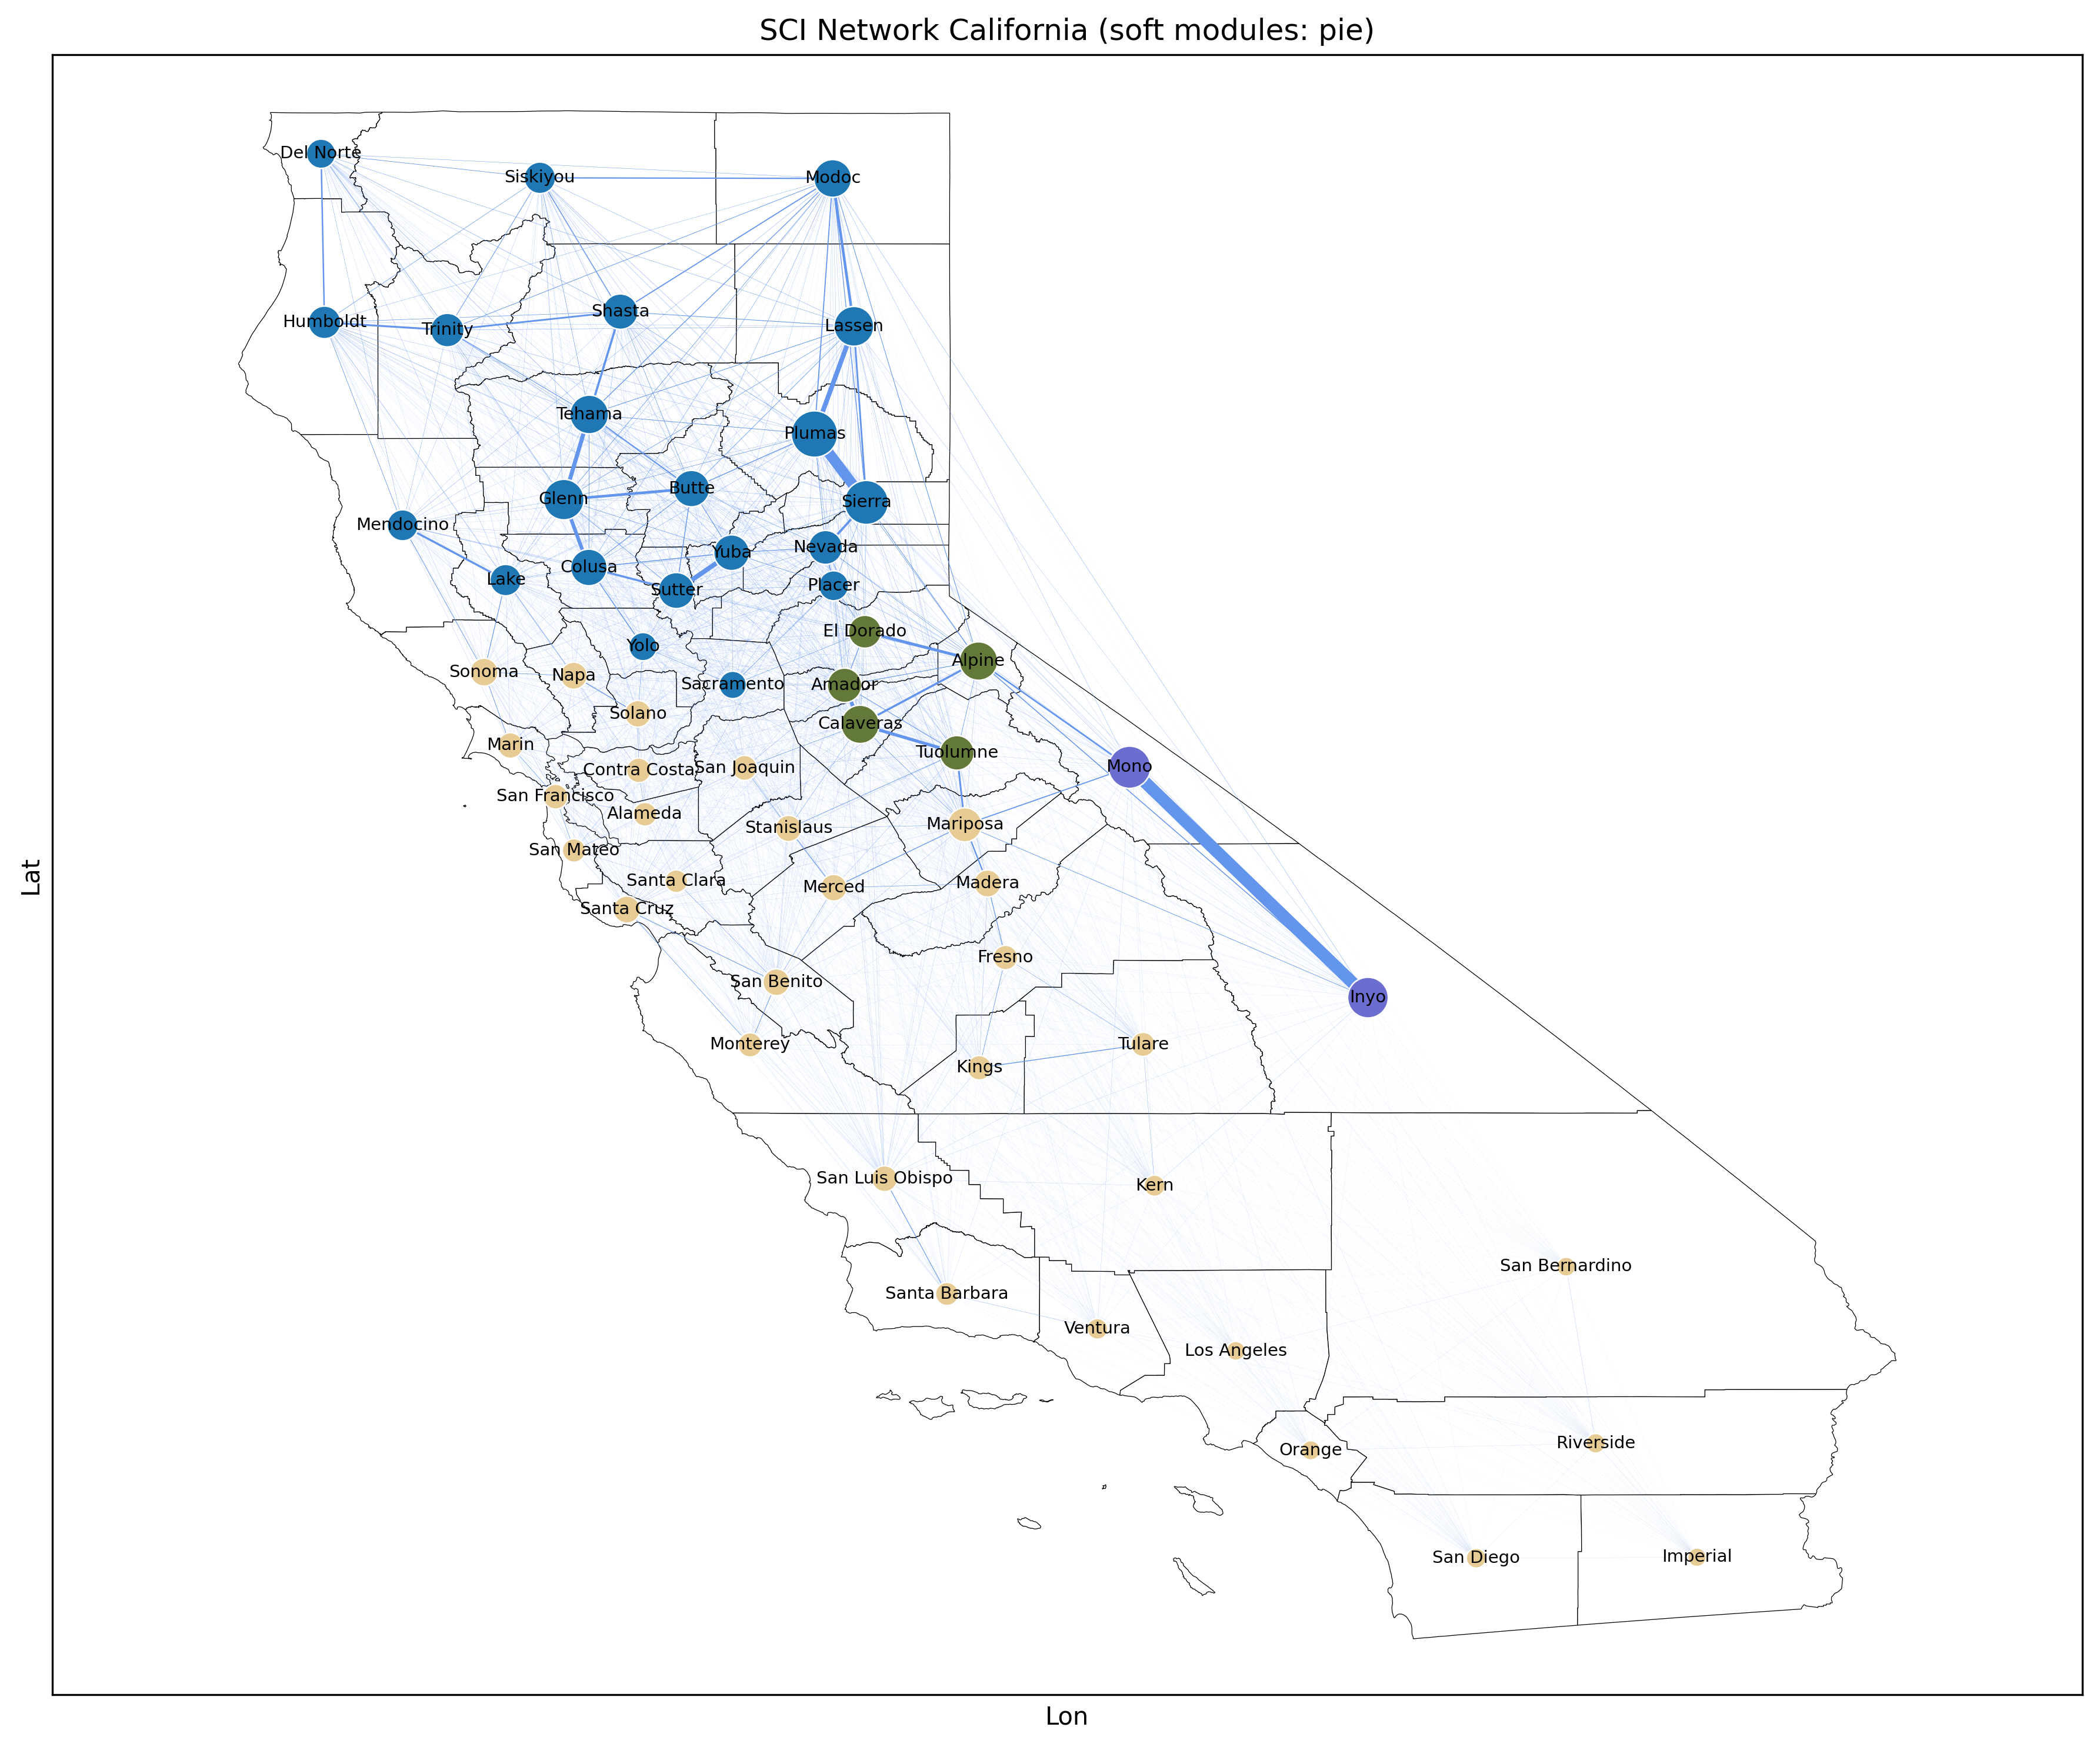

In [106]:
# S: torch.Tensor (anche su CUDA) o np.ndarray di shape (N, K)
# G: networkx con attributi 'lon' e 'lat' per ciascun nodo
plot_state_overlapping(
    state_name_or_code=G.name, #"Texas",  # "CA" oppure "California"
    G=G,
    S=M,
    mode="pie",             # oppure "pie"
    with_labels=True,
    figsize=(12,10),
    node_size=90,             # per "blend"
    node_scale=0.8,           # per "pie"
    max_pie_slices=5          # opzionale, limita n° fette visibili
)